In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import ast

In [26]:
print('Hi')

Hi


In [27]:
filepath = "./simulation_data_2_particles.csv"
df = pd.read_csv(filepath)
df[['x1', 'x2']] = pd.DataFrame(df['x'].apply(ast.literal_eval).tolist(), index=df.index)

In [28]:
df['x1'].std()

np.float64(0.2525990007074115)

In [29]:
df['x1'].describe()

count    1000000.000000
mean          -0.025015
std            0.252599
min           -0.589731
25%           -0.214659
50%           -0.022293
75%            0.179469
max            0.497058
Name: x1, dtype: float64

In [30]:
df['x2'].describe()

count    1000000.000000
mean           0.065614
std            0.252336
min           -0.490456
25%           -0.126249
50%            0.070205
75%            0.265827
max            0.596857
Name: x2, dtype: float64

In [31]:
df['x2'].mean()

np.float64(0.06561376350324127)

In [32]:
df['V'].describe()

count    1.000000e+06
mean     4.065898e-02
std      6.280507e-02
min      2.845973e-14
25%      1.544533e-03
50%      1.286614e-02
75%      5.369648e-02
max      3.906207e-01
Name: V, dtype: float64

In [33]:
df[:10][['time', 'x', 'V']]

,time,x,V
0,0.000,"[0.3444218515250481, 0.2579544029403025]",0.017385
1,0.001,"[0.3444218515250481, 0.2579544029403025]",0.017385
2,0.002,"[0.3444216650575995, 0.25795458940775107]",0.017385
3,0.003,"[0.34442129212270234, 0.25795496234264825]",0.017385
4,0.004,"[0.34442073272072954, 0.25795552174462105]",0.017385
5,0.005,"[0.3444199868524269, 0.2579562676129237]",0.017384
6,0.006,"[0.34441905451891336, 0.25795719994643723]",0.017384
7,0.007,"[0.34441793572168056, 0.25795831874367003]",0.017384
8,0.008,"[0.3444166304625932, 0.2579596240027574]",0.017383
9,0.009,"[0.34441513874388885, 0.25796111572146174]",0.017383


In [34]:
len(df)

1000000

In [35]:
(df[:10]['V'] - df[:10]['V'].mean()) / df[:10]['V'].std()

0    0.944765
1    0.944765
2    0.866033
3    0.708568
4    0.472372
5    0.157447
6   -0.236205
7   -0.708580
8   -1.259677
9   -1.889489
Name: V, dtype: float64

In [36]:
df['V_normalized'] = (df['V'] - df['V'].mean()) / df['V'].std()

In [37]:
df['V_normalized'].describe()

count    1.000000e+06
mean     4.365575e-17
std      1.000000e+00
min     -6.473836e-01
25%     -6.227912e-01
50%     -4.425254e-01
75%      2.075867e-01
max      5.572189e+00
Name: V_normalized, dtype: float64

In [38]:
0.001, 0.0011, 0.0012, 0.0013

-0.2, -0.1, 0.1, 0.2

(-0.2, -0.1, 0.1, 0.2)

In [39]:
df

,simulation_id,time,x,V,x1,x2,V_normalized
0,0,0.000,"[0.3444218515250481, 0.2579544029403025]",1.738505e-02,0.344422,0.257954,-0.370574
1,0,0.001,"[0.3444218515250481, 0.2579544029403025]",1.738505e-02,0.344422,0.257954,-0.370574
2,0,0.002,"[0.3444216650575995, 0.25795458940775107]",1.738499e-02,0.344422,0.257955,-0.370575
3,0,0.003,"[0.34442129212270234, 0.25795496234264825]",1.738485e-02,0.344421,0.257955,-0.370577
4,0,0.004,"[0.34442073272072954, 0.25795552174462105]",1.738464e-02,0.344421,0.257956,-0.370581
...,...,...,...,...,...,...,...
999995,99,9.995,"[-0.19474921387216068, -0.09627521119722328]",1.164334e-06,-0.194749,-0.096275,-0.647365
999996,99,9.996,"[-0.19526016995621007, -0.09576425511317391]",1.270509e-07,-0.195260,-0.095764,-0.647382
999997,99,9.997,"[-0.19577112756625678, -0.09525329750312721]",1.340740e-07,-0.195771,-0.095253,-0.647382
999998,99,9.998,"[-0.19628208568038863, -0.09474233938899534]",1.185409e-06,-0.196282,-0.094742,-0.647365


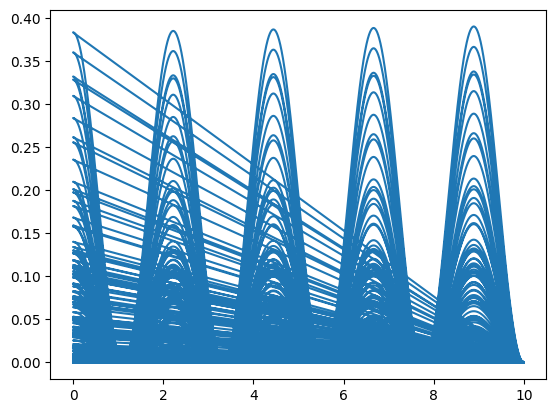

In [40]:
plt.plot(df['time'], df['V'])

In [41]:
df[(df['V'] < 10) & (df['V'] > 8) & (df['time'] >= 0.2) & (df['time'] < 1.0)]['simulation_id'].unique()

array([], dtype=int64)

In [42]:
k = 1
d=0.1
df['V_pred'] = 0.5 * k * (df['x2'] - df['x1'] - d) ** 2


In [43]:
df[['V_pred', 'V']].iloc[0]

V_pred    0.017385
V         0.017385
Name: 0, dtype: float64

In [44]:
len(df)

1000000

In [51]:
sum(df['V_pred'].round(6) == df['V'].round(6))

1000000

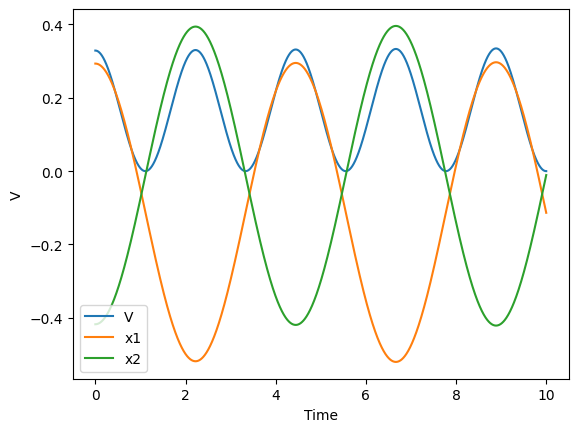

In [53]:
plot_xs_and_V_against_time(df, 48)

In [54]:
def plot_xs_and_V_against_time(df, simulation_id):
    df_filtered = df[df['simulation_id'] == simulation_id]
    t = df_filtered['time']
    V = df_filtered['V']
    x1 = df_filtered['x1']
    x2 = df_filtered['x2']
    plt.plot(t, V, label="V")
    plt.plot(t, x1, label='x1')
    plt.plot(t, x2, label='x2')
    plt.xlabel("Time")
    plt.ylabel("V")
    plt.legend()
    plt.show()

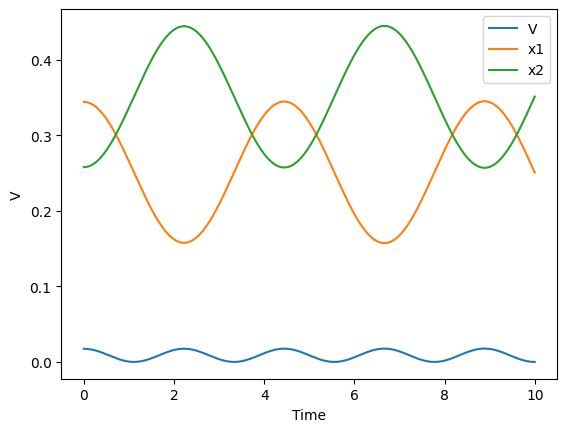

In [55]:
plot_xs_and_V_against_time(df, 0)

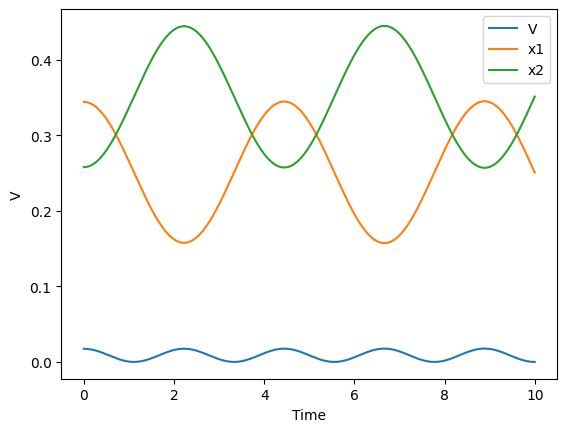

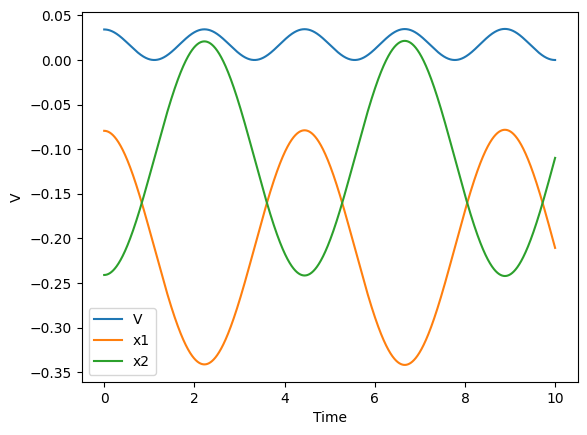

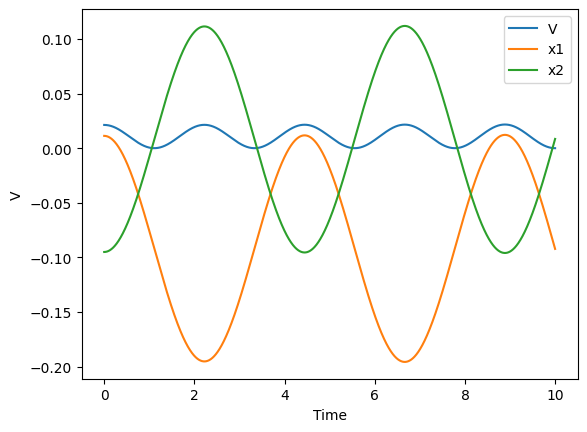

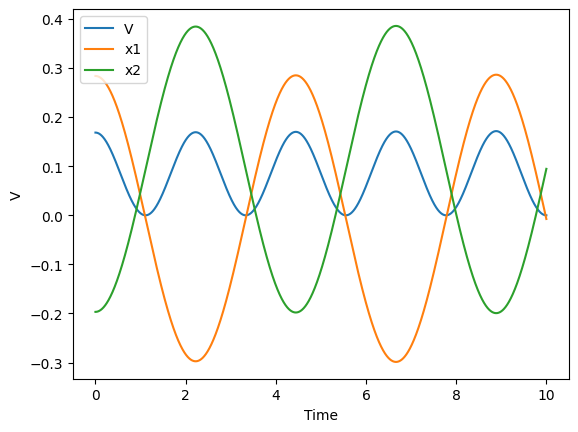

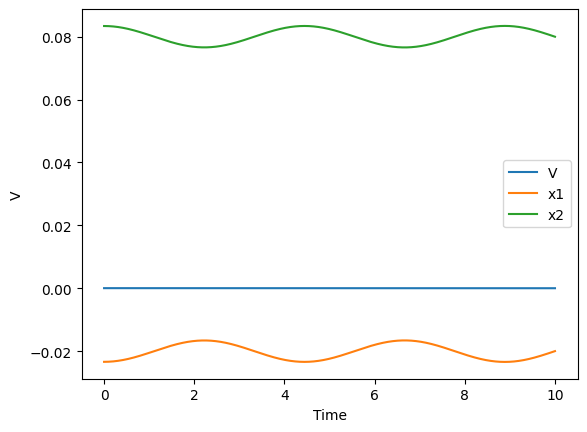

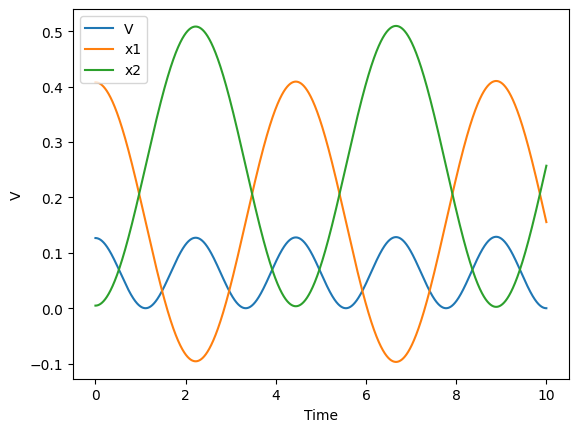

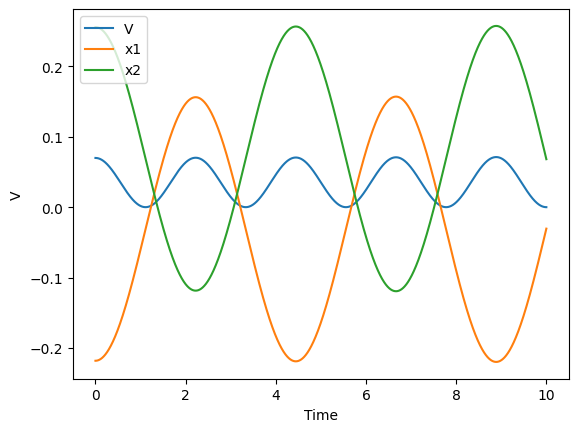

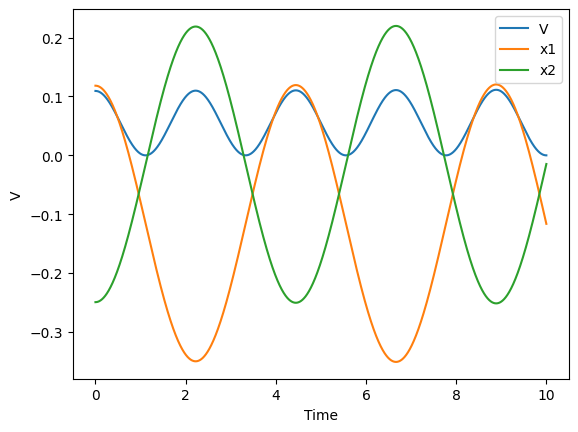

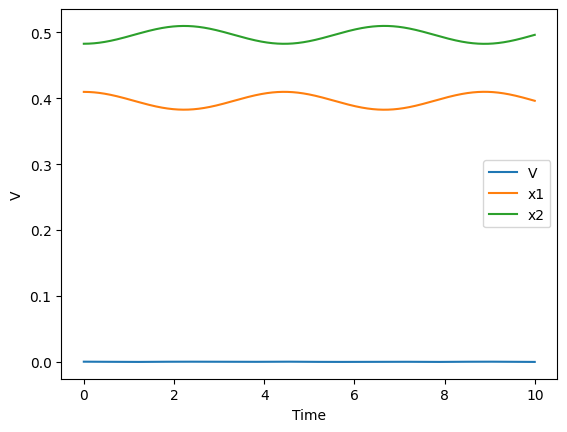

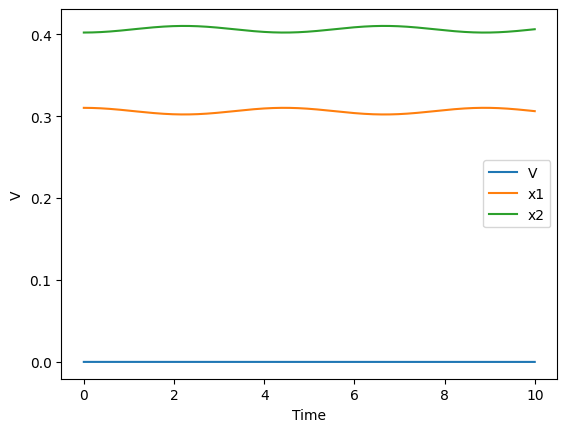

In [56]:
for i in range(10):
    plot_xs_and_V_against_time(df, i)

positions [[0.2933250841302242, -0.4176270118033526], [0.2933250841302242, -0.4176270118033526], [0.29332427317812826, -0.4176262008512567], [0.2933226512739364, -0.41762457894706484], [0.29332021841927053, -0.41762214609239895], [0.29331697461737444, -0.41761890229050286], [0.2933129198731138, -0.41761484754624223], [0.2933080541929763, -0.4176099818661047], [0.2933023775850713, -0.41760430525819975], [0.2932958900591303, -0.41759781773225874], [0.29328859162650645, -0.41759051929963487], [0.2932804823001748, -0.4175824099733032], [0.2932715620947322, -0.41757348976786063], [0.29326183102639736, -0.4175637586995258], [0.2932512891130106, -0.41755321678613905], [0.29323993637403417, -0.4175418640471626], [0.29322777283055185, -0.41752970050368027], [0.2932147985052691, -0.4175167261783975], [0.29320101342251303, -0.41750294109564146], [0.2931864176082323, -0.4174883452813607], [0.293171011089997, -0.4174729387631254], [0.29315479389699883, -0.41745672157012725], [0.2931377660600508, -0

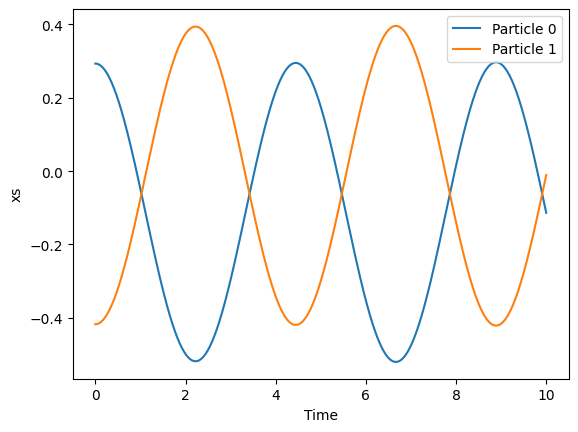

In [57]:
plot_xs_against_time(df, 48)

<Axes: >

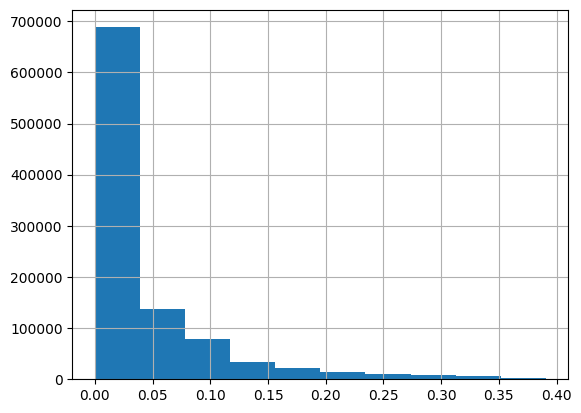

In [58]:
df['V'].hist()

In [59]:

def create_simulation_video(df, simulation_id, frames, path_prefix):
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    fig, ax = plt.subplots()
    scat = ax.scatter([], [], s=80)

    ax.set_xlim(-1, 1)   
    ax.set_ylim(-0.2, 0.2)  
    ax.set_yticks([])

    def init():
        scat.set_offsets(np.empty((0, 2)))
        return (scat,)

    def update(frame):
        xs = ast.literal_eval(df[df["simulation_id"] == simulation_id]['x'].iloc[frame])
        # print('xs', xs)
        ys = [0] * len(xs)
        scat.set_offsets(np.c_[xs, ys])
        scat.set_facecolors(colors[:len(xs)])
        return (scat,)

    ani = FuncAnimation(fig, update, frames=frames,
                                init_func=init, blit=True, interval=20)

    ani.save(path_prefix + "_"+ str(simulation_id) +".mp4", writer="ffmpeg", fps=30)

In [60]:
# create_simulation_video(df, 0, 1000, "./simulations/two_particle_sim")

In [61]:
# for i in range(2):
#     create_simulation_video(df, i, 1000, "./simulations/two_particle_sim")

In [62]:
def plot_V_against_time(df, simulation_id):
    t = df[df['simulation_id'] == simulation_id]['time']
    V = df[df['simulation_id'] == simulation_id]['V']
    plt.plot(t, V)
    plt.xlabel("Time")
    plt.ylabel("V")
    plt.legend()
    plt.show()



In [63]:
def plot_xs_against_time(df, simulation_id):

    positions = [ast.literal_eval(pos) for pos in df[df["simulation_id"] == simulation_id]['x'].tolist()]
    t = df[df['simulation_id'] == simulation_id]['time']
    print('positions', positions)

    p0_positions = [el[0] for el in positions]
    p1_positions = [el[1] for el in positions]
    print(p0_positions)

    plt.plot(t, p0_positions, label="Particle 0")
    plt.plot(t, p1_positions, label="Particle 1")
    plt.xlabel("Time")
    plt.ylabel("xs")
    plt.legend()
    plt.show()



In [64]:
def plot_xs_and_V_against_time(df, simulation_id):
    t = df[df['simulation_id'] == simulation_id]['time']
    V = df[df['simulation_id'] == simulation_id]['V']
    x1 = df[df['simulation_id'] == simulation_id]['x1']
    x2 = df[df['simulation_id'] == simulation_id]['x2']
    plt.plot(t, V, label="V")
    plt.plot(t, x1, label='x1')
    plt.plot(t, x2, label='x2')
    plt.xlabel("Time")
    plt.ylabel("V")
    plt.legend()
    plt.show()

positions [[-0.079428419169155, -0.24108324970703665], [-0.079428419169155, -0.24108324970703665], [-0.07942868082398553, -0.24108298805220613], [-0.07942920413364661, -0.24108246474254505], [-0.07942998909761491, -0.24108167977857675], [-0.07943103571484382, -0.24108063316134784], [-0.07943234398376342, -0.24107932489242825], [-0.07943391390228047, -0.2410777549739112], [-0.07943574546777842, -0.24107592340841325], [-0.07943783867711744, -0.24107383019907422], [-0.07944019352663441, -0.24107147534955725], [-0.07944281001214289, -0.24106885886404877], [-0.0794456881289332, -0.24106598074725846], [-0.07944882787177236, -0.2410628410044193], [-0.07945222923490414, -0.2410594396412875], [-0.07945589221204905, -0.2410557766641426], [-0.07945981679640436, -0.2410518520797873], [-0.07946400298064413, -0.24104766589554752], [-0.07946845075691918, -0.24104321811927246], [-0.07947316011685714, -0.2410385087593345], [-0.07947813105156247, -0.24103353782462916], [-0.07948336355161643, -0.24102830

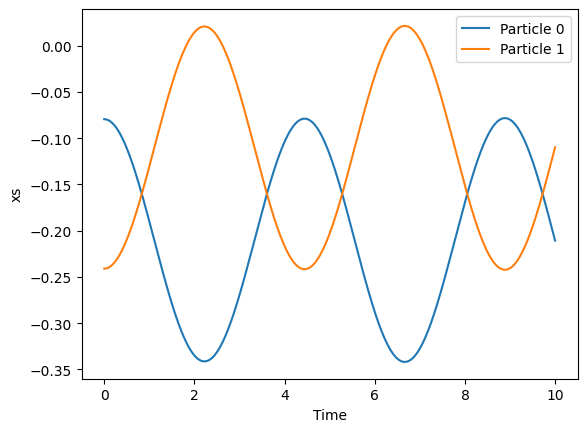

In [65]:
plot_xs_against_time(df, 1)

positions [[0.3444218515250481, 0.2579544029403025], [0.3444218515250481, 0.2579544029403025], [0.3444216650575995, 0.25795458940775107], [0.34442129212270234, 0.25795496234264825], [0.34442073272072954, 0.25795552174462105], [0.3444199868524269, 0.2579562676129237], [0.34441905451891336, 0.25795719994643723], [0.34441793572168056, 0.25795831874367003], [0.3444166304625932, 0.2579596240027574], [0.34441513874388885, 0.25796111572146174], [0.344413460568178, 0.2579627938971726], [0.34441159593844417, 0.2579646585269064], [0.34440954485804365, 0.25796670960730694], [0.34440730733070574, 0.25796894713464485], [0.34440488336053254, 0.25797137110481805], [0.34440227295199916, 0.25797398151335144], [0.34439947610995353, 0.25797677835539706], [0.34439649283961643, 0.25797976162573416], [0.3443933231465816, 0.257982931318769], [0.34438996703681557, 0.257986287428535], [0.3443864245166577, 0.2579898299486929], [0.3443826955928202, 0.2579935588725304], [0.34437878027238816, 0.25799747419296243],

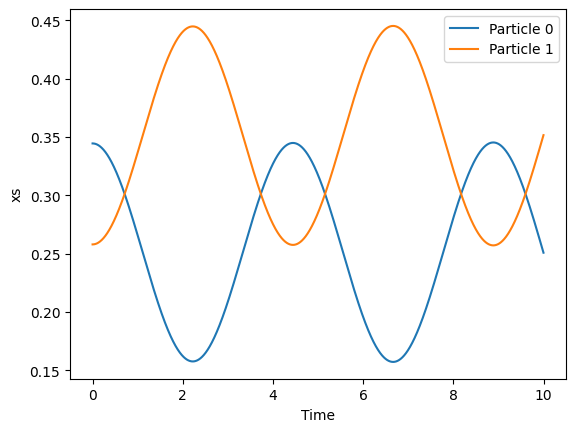

positions [[-0.079428419169155, -0.24108324970703665], [-0.079428419169155, -0.24108324970703665], [-0.07942868082398553, -0.24108298805220613], [-0.07942920413364661, -0.24108246474254505], [-0.07942998909761491, -0.24108167977857675], [-0.07943103571484382, -0.24108063316134784], [-0.07943234398376342, -0.24107932489242825], [-0.07943391390228047, -0.2410777549739112], [-0.07943574546777842, -0.24107592340841325], [-0.07943783867711744, -0.24107383019907422], [-0.07944019352663441, -0.24107147534955725], [-0.07944281001214289, -0.24106885886404877], [-0.0794456881289332, -0.24106598074725846], [-0.07944882787177236, -0.2410628410044193], [-0.07945222923490414, -0.2410594396412875], [-0.07945589221204905, -0.2410557766641426], [-0.07945981679640436, -0.2410518520797873], [-0.07946400298064413, -0.24104766589554752], [-0.07946845075691918, -0.24104321811927246], [-0.07947316011685714, -0.2410385087593345], [-0.07947813105156247, -0.24103353782462916], [-0.07948336355161643, -0.24102830

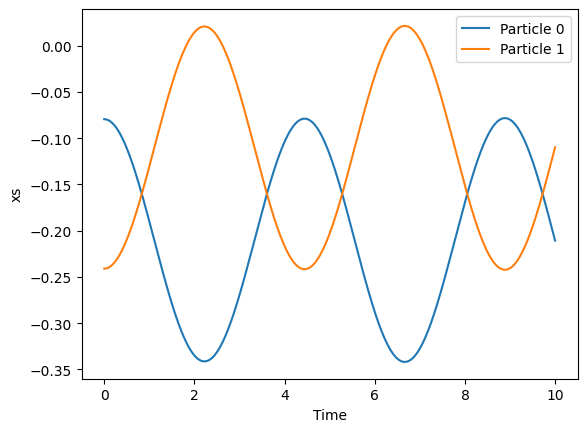

positions [[0.01127472136860852, -0.09506586254958571], [0.01127472136860852, -0.09506586254958571], [0.011274515028024602, -0.09506565620900179], [0.011274102346856767, -0.09506524352783395], [0.011273483325517693, -0.09506462450649487], [0.011272657964832745, -0.09506379914580992], [0.011271626266039964, -0.09506276744701714], [0.011270388230790074, -0.09506152941176725], [0.01126894386114647, -0.09506008504212364], [0.011267293159585223, -0.0950584343405624], [0.011265436128995074, -0.09505657730997225], [0.011263372772677424, -0.09505451395365459], [0.011261103094346336, -0.09505224427532351], [0.011258627098128521, -0.09504976827910569], [0.011255944788563337, -0.0950470859695405], [0.011253056170602774, -0.09504419735157994], [0.011249961249611454, -0.09504110243058862], [0.011246660031366611, -0.09503780121234379], [0.011243152522058089, -0.09503429370303526], [0.011239438728288323, -0.0950305799092655], [0.011235518657072332, -0.0950266598380495], [0.011231392315837703, -0.0950

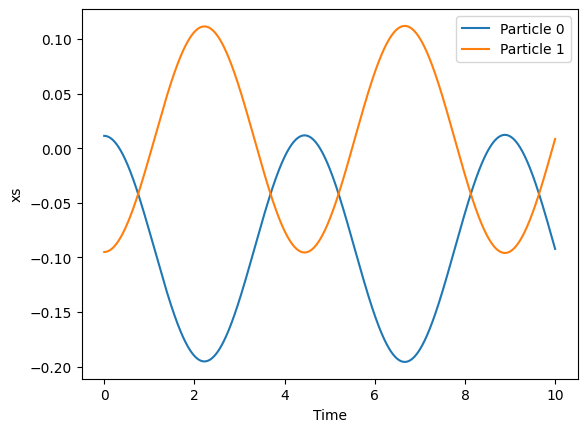

positions [[0.2837985890347726, -0.19668727392107255], [0.2837985890347726, -0.19668727392107255], [0.2837980085489097, -0.1966866934352096], [0.28379684757718376, -0.19668553246348366], [0.28379510612075587, -0.19668379100705577], [0.2837927841819479, -0.19668146906824782], [0.28378988176424286, -0.19667856665054276], [0.2837863988722845, -0.19667508375858445], [0.2837823355118778, -0.19667102039817771], [0.28377769168998845, -0.19666637657628835], [0.28377246741474316, -0.19666115230104309], [0.2837666626954296, -0.19665534758172956], [0.28376027754249633, -0.19664896242879631], [0.2837533119675528, -0.19664199685385278], [0.2837457659833693, -0.19663445086966927], [0.283737639603877, -0.19662632449017695], [0.28372893284416784, -0.19661761773046776], [0.2837196457204946, -0.1966083306067945], [0.2837097782502707, -0.19659846313657064], [0.2836993304520705, -0.19658801533837048], [0.283688302345629, -0.19657698723192893], [0.28367669395184164, -0.19656537883814157], [0.28366450529276

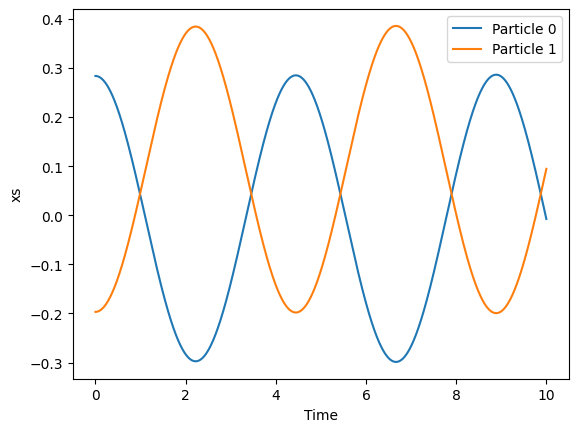

positions [[-0.02340304584764419, 0.0833820394550312], [-0.02340304584764419, 0.0833820394550312], [-0.023403039062558886, 0.0833820326699459], [-0.02340302549238828, 0.08338201909977529], [-0.02340300513714594, 0.08338199874453295], [-0.02340297799685901, 0.08338197160424601], [-0.023402944071568198, 0.0833819376789552], [-0.023402903361327786, 0.08338189696871479], [-0.02340285586620562, 0.08338184947359262], [-0.023402801586283127, 0.08338179519367013], [-0.023402740521655294, 0.0833817341290423], [-0.02340267267243068, 0.08338166627981769], [-0.023402598038731418, 0.08338159164611843], [-0.0234025166206932, 0.08338151022808021], [-0.0234024284184653, 0.08338142202585232], [-0.02340233343221055, 0.08338132703959757], [-0.023402231662105356, 0.08338122526949238], [-0.02340212310833969, 0.0833811167157267], [-0.02340200777111709, 0.08338100137850411], [-0.023401885650654666, 0.08338087925804169], [-0.023401756747183096, 0.08338075035457011], [-0.023401621060946617, 0.08338061466833363

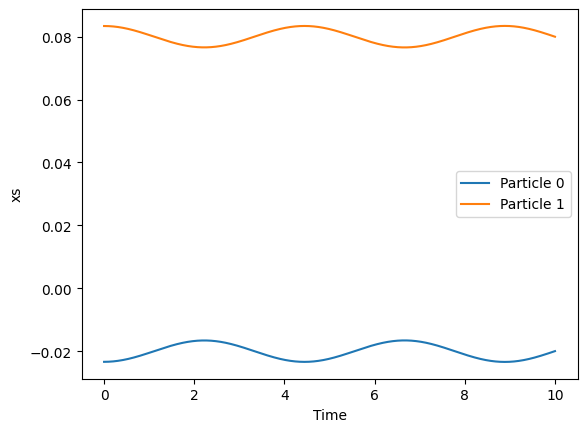

positions [[0.4081128851953352, 0.004686855817390256], [0.4081128851953352, 0.004686855817390256], [0.4081123817693058, 0.004687359243419635], [0.408111374917247, 0.00468836609547839], [0.40810986464016574, 0.004689876372559672], [0.4081078509400756, 0.004691890072649776], [0.40810533381999725, 0.004694407192728147], [0.408102313283958, 0.0046974277287673855], [0.4080987893369922, 0.0047009516757332516], [0.4080947619851408, 0.004704979027584673], [0.4080902312354517, 0.0047095097772737555], [0.4080851970959796, 0.0047145439167457955], [0.4080796595757861, 0.004720081436939294], [0.40807361868493947, 0.004726122327785971], [0.4080670744345147, 0.004732666578210787], [0.4080600268365935, 0.0047397141761319605], [0.40805247590426447, 0.00474726510846099], [0.4080444216516228, 0.00475531936110268], [0.4080358640937703, 0.004763876918955166], [0.4080268032468155, 0.004772937765909942], [0.4080172391278736, 0.004782501884851893], [0.4080071717550661, 0.004792569257659325], [0.40799660114752

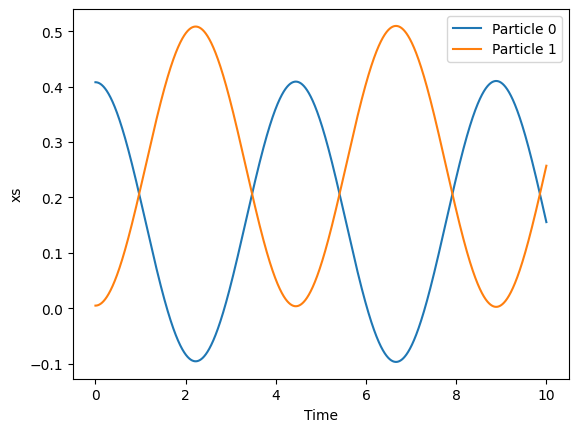

positions [[-0.21816215560029617, 0.25580420415722394], [-0.21816215560029617, 0.25580420415722394], [-0.2181617816339364, 0.25580383019086417], [-0.2181610337012169, 0.25580308225814463], [-0.21815991180288555, 0.2558019603598133], [-0.21815841594043825, 0.255800464497366], [-0.2181565461161188, 0.2557985946730465], [-0.21815430233291888, 0.2557963508898466], [-0.2181516845945782, 0.2557937331515059], [-0.21814869290558428, 0.25579074146251196], [-0.2181453272711726, 0.2557873758281003], [-0.21814158769732658, 0.25578363625425427], [-0.21813747419077745, 0.25577952274770516], [-0.21813298675900436, 0.2557750353159321], [-0.21812812541023435, 0.25577017396716206], [-0.21812289015344227, 0.25576493871037], [-0.21811728099835082, 0.2557593295552785], [-0.2181112979554305, 0.2557533465123582], [-0.2181049410358996, 0.2557469895928273], [-0.21809821025172427, 0.255740258808652], [-0.21809110561561829, 0.255733154172546], [-0.21808362714104323, 0.25572567569797094], [-0.21807577484220841, 0

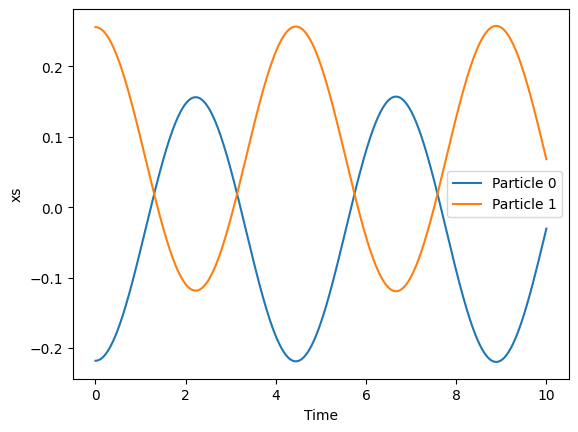

positions [[0.11836899667533163, -0.24949365863755946], [0.11836899667533163, -0.24949365863755946], [0.11836852881267632, -0.24949319077490414], [0.11836759308736569, -0.24949225504959352], [0.11836618950033548, -0.2494908514625633], [0.11836431805345712, -0.24948898001568495], [0.11836197874953781, -0.24948664071176563], [0.11835917159232043, -0.24948383355454826], [0.11835589658648359, -0.2494805585487114], [0.1183521537376416, -0.2494768156998694], [0.11834794305234447, -0.24947260501457227], [0.1183432645380779, -0.24946792650030572], [0.11833811820326327, -0.2494627801654911], [0.1183325040572576, -0.24945716601948542], [0.11832642211035357, -0.24945108407258137], [0.11831987237377946, -0.24944453433600727], [0.11831285485969917, -0.24943751682192697], [0.11830536958121216, -0.24943003154343996], [0.11829741655235347, -0.24942207851458126], [0.11828899578809365, -0.24941365775032145], [0.11828010730433877, -0.24940476926656657], [0.11827075111793035, -0.24939541308015817], [0.118

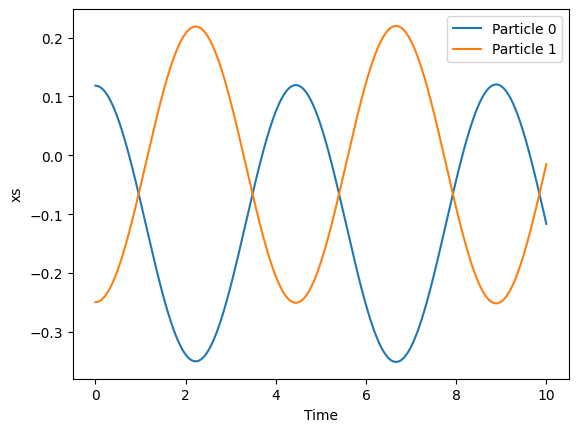

positions [[0.4097462559682401, 0.4827854760376531], [0.4097462559682401, 0.4827854760376531], [0.40974622900746016, 0.48278550299843304], [0.4097461750859003, 0.4827855569199929], [0.4097460942036144, 0.4827856378022788], [0.40974598636071036, 0.48278574564518284], [0.40974585155734994, 0.48278588044854326], [0.4097456897937488, 0.4827860422121444], [0.40974550107017654, 0.48278623093571665], [0.4097452853869567, 0.4827864466189365], [0.4097450427444667, 0.4827866892614265], [0.40974477314313795, 0.48278695886275524], [0.4097444765834557, 0.4827872554224375], [0.4097441530659592, 0.482787578939934], [0.4097438025912415, 0.4827879294146517], [0.4097434251599497, 0.4827883068459435], [0.40974302077278474, 0.48278871123310846], [0.40974258943050146, 0.48278914257539174], [0.4097421311339086, 0.4827896008719846], [0.4097416458838689, 0.4827900861220243], [0.40974113368129894, 0.48279059832459426], [0.4097405945271692, 0.482791137478724], [0.4097400284225041, 0.4827917035833891], [0.409739

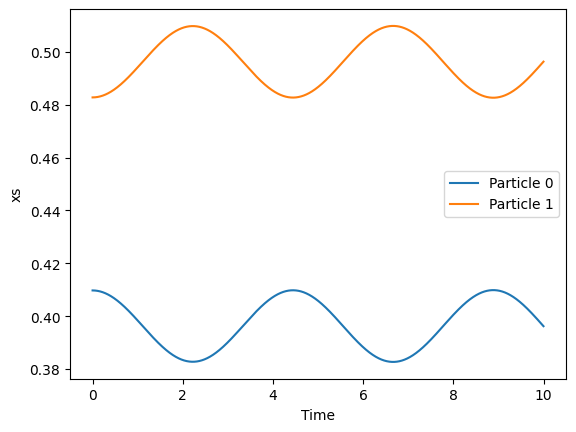

positions [[0.31021723599658957, 0.4021659504395827], [0.31021723599658957, 0.4021659504395827], [0.310217227945304, 0.4021659584908683], [0.3102172118427329, 0.4021659745934394], [0.3102171876888923, 0.40216599874728], [0.31021715548381446, 0.4021660309523578], [0.3102171152275477, 0.4021660712086246], [0.3102170669201564, 0.4021661195160159], [0.3102170105617211, 0.4021661758744512], [0.31021694615233836, 0.4021662402838339], [0.310216873692121, 0.4021663127440513], [0.3102167931811977, 0.40216639325497455], [0.3102167046197135, 0.40216648181645875], [0.31021660800782935, 0.4021665784283429], [0.3102165033457224, 0.40216668309044984], [0.3102163906335859, 0.40216679580258635], [0.31021626987162915, 0.4021669165645431], [0.31021614106007755, 0.4021670453760947], [0.3102160041991726, 0.40216718223699965], [0.310215859289172, 0.40216732714700026], [0.31021570633034945, 0.4021674801058228], [0.3102155453229947, 0.40216764111317754], [0.3102153762674138, 0.40216781016875847], [0.310215199

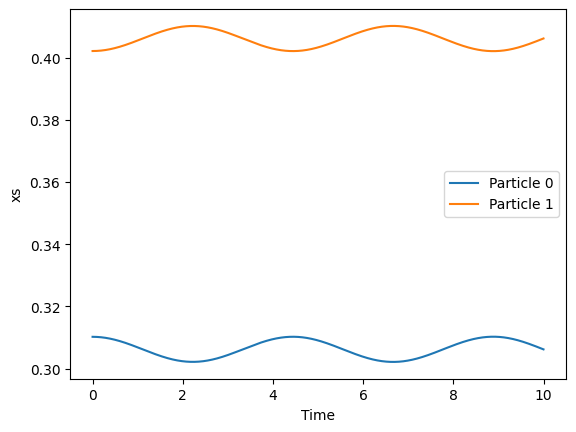

In [66]:
for i in range(10):
    plot_xs_against_time(df, i)

## Generate simple data

In [67]:
x = np.random.random([1000, 2])
y = x[:, 0] + x[:, 1]


df = pd.DataFrame({"x": x.tolist(), "V": y.tolist()})
print(df.head())
df.to_csv("x1_plus_x2.csv")

# 

x = np.random.random([1000, 2])
y = x[:, 0] * x[:, 1]


df = pd.DataFrame({"x": x.tolist(), "V": y.tolist()})
print(df.head())
df.to_csv("x1_times_x2.csv")

                                           x         V
0  [0.07222472609309871, 0.6179807204125954]  0.690205
1   [0.9095644588322195, 0.9189008482469257]  1.828465
2   [0.9947954862569266, 0.1441418294894461]  1.138937
3  [0.06672190282548396, 0.7892003833725724]  0.855922
4  [0.39988583037624836, 0.6553555847460503]  1.055241
                                           x         V
0   [0.7609488849518684, 0.6125619153958952]  0.466128
1   [0.6986658651355696, 0.8724291872807992]  0.609536
2  [0.34724893103299825, 0.6338401540846678]  0.220100
3  [0.33154641428488685, 0.5575641360838949]  0.184858
4   [0.7056577145656785, 0.8785370148893248]  0.619946
